## Pinguine

### Aufgabe 1: Daten einlesen und begutachten

In [1]:
import pandas as pd
import numpy as np

In [2]:
data_penguins = pd.read_csv("data/penguins.csv",delimiter=',')
data_penguins.head()

,rowid,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [3]:
data = np.array(data_penguins)
print("Das Array hat %i Zeilen und %i Spalten." %(np.shape(data)))
print("\nErste Zeilen:")
print(data[0:5,:])
print("\nLetzte Zeilen:")
print(data[len(data)-3:,:])


Das Array hat 344 Zeilen und 9 Spalten.

Erste Zeilen:
[[1 'Adelie' 'Torgersen' 39.1 18.7 181.0 3750.0 'male' 2007]
 [2 'Adelie' 'Torgersen' 39.5 17.4 186.0 3800.0 'female' 2007]
 [3 'Adelie' 'Torgersen' 40.3 18.0 195.0 3250.0 'female' 2007]
 [4 'Adelie' 'Torgersen' nan nan nan nan nan 2007]
 [5 'Adelie' 'Torgersen' 36.7 19.3 193.0 3450.0 'female' 2007]]

Letzte Zeilen:
[[342 'Chinstrap' 'Dream' 49.6 18.2 193.0 3775.0 'male' 2009]
 [343 'Chinstrap' 'Dream' 50.8 19.0 210.0 4100.0 'male' 2009]
 [344 'Chinstrap' 'Dream' 50.2 18.7 198.0 3775.0 'female' 2009]]


### Aufgabe 2: Daten aus Array extrahieren und Textausgabe

In [4]:
# Suche Gentoo
Art = np.array(data_penguins['species'])
data_gentoo = data
for i in range(len(Art),0,-1):
    if Art[i-1] != 'Gentoo':
        data_gentoo = np.delete(data_gentoo,i-1, axis=0)


In [5]:
print(data_gentoo[:5,:])

[[153 'Gentoo' 'Biscoe' 46.1 13.2 211.0 4500.0 'female' 2007]
 [154 'Gentoo' 'Biscoe' 50.0 16.3 230.0 5700.0 'male' 2007]
 [155 'Gentoo' 'Biscoe' 48.7 14.1 210.0 4450.0 'female' 2007]
 [156 'Gentoo' 'Biscoe' 50.0 15.2 218.0 5700.0 'male' 2007]
 [157 'Gentoo' 'Biscoe' 47.6 14.5 215.0 5400.0 'male' 2007]]


In [6]:
Mittelwerte = np.nanmean(data_gentoo[:,3:7],axis=0)
print(Mittelwerte)

[47.504878048780476 14.982113821138206 217.1869918699187 5076.016260162602]


In [7]:
print('Die Schnäbel der Eselspinguine sind im Schnitt %.0f mm lang und %.0f mm dick.' %(Mittelwerte[0],Mittelwerte[1]))
print('Die Flossenlänge beträgt etwa %.0f cm.' %(Mittelwerte[2]*0.1))
print('Sie wiegen durchschnittlich %.1f kg.' %(Mittelwerte[3]/1000))

Die Schnäbel der Eselspinguine sind im Schnitt 48 mm lang und 15 mm dick.
Die Flossenlänge beträgt etwa 22 cm.
Sie wiegen durchschnittlich 5.1 kg.


### Aufgabe 3: Daten als Punkte darstellen

In [8]:
import matplotlib.pyplot as plt

In [9]:
# drei Pinguin-Arten
Art = np.array(data_penguins['species'])
data_adelie = data
data_gentoo = data
data_chinstrap = data
for i in range(len(Art),0,-1):
    if Art[i-1] == 'Adelie':
        data_gentoo = np.delete(data_gentoo,i-1, axis=0)
        data_chinstrap = np.delete(data_chinstrap,i-1, axis=0)
    elif Art[i-1] == 'Gentoo':
        data_adelie = np.delete(data_adelie,i-1, axis=0)
        data_chinstrap = np.delete(data_chinstrap,i-1, axis=0)
    elif Art[i-1] == 'Chinstrap':
        data_adelie = np.delete(data_adelie,i-1, axis=0)
        data_gentoo = np.delete(data_gentoo,i-1, axis=0)

# Überprüfung, ob die Auftrennung des Datensatzes für die drei Pinguine geklappt hat 
print('Adelie: '+str(np.shape(data_adelie)))
print('Gentoo: '+str(np.shape(data_gentoo)))
print('Chinstrap: '+str(np.shape(data_chinstrap)))
print('Gesamtanzahl zur Kontrolle: '+str(np.shape(data)))

Adelie: (152, 9)
Gentoo: (124, 9)
Chinstrap: (68, 9)
Gesamtanzahl zur Kontrolle: (344, 9)


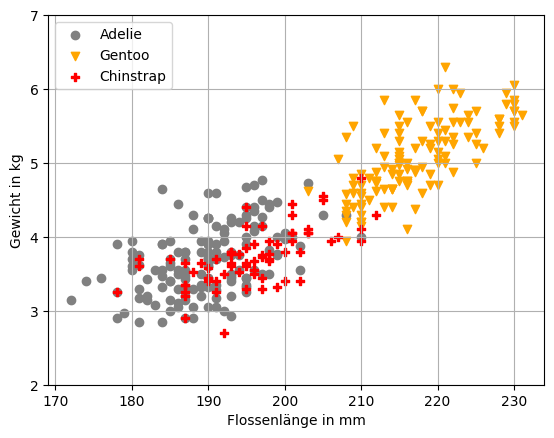

In [10]:
plt.scatter(data_adelie[:,5],data_adelie[:,6]/1000,label='Adelie',color='grey',marker='o')
plt.scatter(data_gentoo[:,5],data_gentoo[:,6]/1000,label='Gentoo',color='orange',marker='v')
plt.scatter(data_chinstrap[:,5],data_chinstrap[:,6]/1000,label='Chinstrap',color='red',marker='P')
plt.xlabel('Flossenlänge in mm')
plt.ylabel('Gewicht in kg')
plt.ylim([2,7])
plt.grid()
plt.legend()
plt.show()

### Aufgabe 4: Max Musterpinguin

In [11]:
# Temporäre Variable für den neuen Pinguin-Datensatz
new_gentoo = np.array(data_gentoo[0,:])  # Kopieren einer Zeile als Vorlage
#falsch    = data_gentoo[0,:]     -> So wird nur eine Kopie des pointers auf den Speicher von data_gentoo erstellt, aber der Inhalt nicht kopiert

new_gentoo[0] = data[-1,0] + 1    # letzter ID-Wert + 1
new_gentoo[1] = 'Gentoo'          # nicht erforderlich
new_gentoo[2] = 'Fantasieland'  
new_gentoo[3] = np.nanmedian(data_gentoo[:,3])
new_gentoo[4] = np.nanmedian(data_gentoo[:,4])
new_gentoo[5] = np.nanmedian(data_gentoo[:,5])
new_gentoo[6] = np.nanmedian(data_gentoo[:,6])
new_gentoo[7] = 'male' 
new_gentoo[8] = 2024

print(new_gentoo)

[345 'Gentoo' 'Fantasieland' 47.3 15.0 216.0 5000.0 'male' 2024]


In [12]:
# new_gentoo hat noch nicht die richtige Form
print(np.shape(data_gentoo))
print(np.shape(new_gentoo))

(124, 9)
(9,)


In [13]:
# new_gentoo soll ein 2-Dim-Array mit 1 Zeile und 9 Spalten sein:
new_gentoo = np.reshape(new_gentoo,(1,9))
print(np.shape(new_gentoo))

(1, 9)


In [14]:
Zeilen_vor_append = np.shape(data_gentoo)[0]

In [15]:
# Zeile hinter die letzte Zeile anhängen
data_gentoo = np.append(data_gentoo, new_gentoo, axis=0)

In [16]:
# Ausgabe zur Kontrolle
print(data_gentoo[-5:,:])
print('\nVorher waren es '+str(Zeilen_vor_append)+' Zeilen. Nun hat der Datensatz '+str(np.shape(data_gentoo)[0])+' Zeilen.')

[[273 'Gentoo' 'Biscoe' 46.8 14.3 215.0 4850.0 'female' 2009]
 [274 'Gentoo' 'Biscoe' 50.4 15.7 222.0 5750.0 'male' 2009]
 [275 'Gentoo' 'Biscoe' 45.2 14.8 212.0 5200.0 'female' 2009]
 [276 'Gentoo' 'Biscoe' 49.9 16.1 213.0 5400.0 'male' 2009]
 [345 'Gentoo' 'Fantasieland' 47.3 15.0 216.0 5000.0 'male' 2024]]

Vorher waren es 124 Zeilen. Nun hat der Datensatz 125 Zeilen.


### Aufgabe 5: Zufallszahlen

In [17]:
# min und max
val_min = np.min(data_gentoo[:,3:7],axis=0)
print("Kleinste Werte:")
print(val_min)
val_max = np.max(data_gentoo[:,3:7],axis=0)
print("Größte Werte:")
print(val_max)

Kleinste Werte:
[45.2 14.3 212.0 4850.0]
Größte Werte:
[50.4 16.1 222.0 5750.0]


C:\Users\User\Desktop\WPy64-31180\python-3.11.8.amd64\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [18]:
# Zufallszahlengenerator initialisieren
RG = np.random.default_rng(seed=None)
# Testweise eine passende Zufallszahl generieren 
RG.integers(low=val_min[0]*10,high=val_max[0]*10)/10

45.8

In [19]:
# Gentoo Datensatz nochmal neu erstellen (nur Kopie von oben)
Art = np.array(data_penguins['species'])
data_gentoo = np.array(data)
for i in range(len(Art),0,-1):
    if Art[i-1] != 'Gentoo':
        data_gentoo = np.delete(data_gentoo,i-1, axis=0)
Zeilen_vor_append = np.shape(data_gentoo)[0]

In [20]:
# Temporäre Variable für den neuen Pinguin-Datensatz
# Möglichkeit 1: einen Datensatz (z.B. den letzten) als Vorlage kopieren
new_gentoo = np.array(data_gentoo[-1,:])
new_gentoo = np.reshape(new_gentoo,(1,9))

# Möglichkeit 2: leeres Array mit 1 Zeile und 9 Spalten mit Nullen anlegen
# Der Array-Datenytp muss dann allerdings gleich sein zu "data-gentoo", also "object". Mit object können in einem Array Texte und Zahlen verarbeitet werden.
new_gentoo = np.zeros((1,9), dtype='object')

print(np.shape(new_gentoo)) 
new_gentoo

(1, 9)


array([[0, 0, 0, 0, 0, 0, 0, 0, 0]], dtype=object)

In [21]:
# Schleife für 10 Pinguin-"Messungen"
for i in range(0,10):
    # Werte für einen neuen Datensatz generieren
    new_gentoo[0,0] = data[-1,0] + 1 + i   # letzter ID-Wert von data + 1 + i
    new_gentoo[0,1] = 'Gentoo'              
    new_gentoo[0,2] = 'Fantasieland'  
    new_gentoo[0,3] = RG.integers(low=val_min[0]*10,high=val_max[0]*10)/10  # Zufallszahl
    new_gentoo[0,4] = RG.integers(low=val_min[1]*10,high=val_max[1]*10)/10  # Zufallszahl
    new_gentoo[0,5] = RG.integers(low=val_min[2]*10,high=val_max[2]*10)/10  # Zufallszahl
    new_gentoo[0,6] = RG.integers(low=val_min[3]*10,high=val_max[3]*10)/10  # Zufallszahl
    if i < 5:
        new_gentoo[0,7] = 'female' 
    else:
        new_gentoo[0,7] = 'male' 
    new_gentoo[0,8] = 2024 
    # Neuen Datensatz an "data-gentoo" anhängen
    data_gentoo = np.append(data_gentoo, new_gentoo, axis=0)   

In [22]:
# Ausgabe der letzten 12 Zeilen zur Überprüfung:
print(data_gentoo[-12:,:])

print('\nVorher waren es '+str(Zeilen_vor_append)+' Zeilen. Nun hat der Datensatz '+str(np.shape(data_gentoo)[0])+' Zeilen.')

[[275 'Gentoo' 'Biscoe' 45.2 14.8 212.0 5200.0 'female' 2009]
 [276 'Gentoo' 'Biscoe' 49.9 16.1 213.0 5400.0 'male' 2009]
 [345 'Gentoo' 'Fantasieland' 47.6 15.8 220.0 5721.1 'female' 2024]
 [346 'Gentoo' 'Fantasieland' 45.3 14.9 219.8 5207.0 'female' 2024]
 [347 'Gentoo' 'Fantasieland' 48.3 14.3 213.6 4888.6 'female' 2024]
 [348 'Gentoo' 'Fantasieland' 47.2 15.3 218.3 5244.8 'female' 2024]
 [349 'Gentoo' 'Fantasieland' 49.6 15.8 216.5 5741.8 'female' 2024]
 [350 'Gentoo' 'Fantasieland' 48.5 15.7 212.4 5246.6 'male' 2024]
 [351 'Gentoo' 'Fantasieland' 48.2 14.6 220.1 5622.8 'male' 2024]
 [352 'Gentoo' 'Fantasieland' 45.5 15.4 219.1 5105.4 'male' 2024]
 [353 'Gentoo' 'Fantasieland' 49.3 15.6 220.0 5632.2 'male' 2024]
 [354 'Gentoo' 'Fantasieland' 45.5 14.4 216.2 4918.1 'male' 2024]]

Vorher waren es 124 Zeilen. Nun hat der Datensatz 134 Zeilen.
